## 1. Setup

Setiap severity memiliki dataframe missing, boolean mask, dan nilai ground truth pada posisi yang di-mask. Semua fungsi mengembalikan salinan dataframe agar input tidak berubah. Evaluasi hanya dilakukan pada `mask == True`, bukan pada nilai yang sejak awal tersedia.

In [1]:
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MASK_DIR = PROJECT_ROOT / "data" / "masks"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
IMPUTED_DIR = PROJECT_ROOT / "data" / "imputed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
IMPUTED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEVERITY_LEVELS = [10, 20, 30, 40, 50]
IMPUTED_COLUMNS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]

coordinates = pd.read_csv(PROCESSED_DIR / "station_coordinates.csv")
coordinates = coordinates.set_index("station")[["lat", "lon"]]
data_by_severity = {}
for severity in SEVERITY_LEVELS:
    with (MASK_DIR / f"mask_severity_{severity}.pkl").open("rb") as mask_file:
        mask = pickle.load(mask_file)
    with (MASK_DIR / f"masked_ground_truth_severity_{severity}.pkl").open("rb") as values_file:
        ground_truth_values = pickle.load(values_file)
    missing_df = pd.read_parquet(MASK_DIR / f"df_missing_severity_{severity}.parquet")
    missing_df["datetime"] = pd.to_datetime(missing_df["datetime"])
    data_by_severity[severity] = {
        "df": missing_df.reset_index(drop=True),
        "mask": mask.reset_index(drop=True),
        "ground_truth": ground_truth_values.reset_index(drop=True),
    }

print(f"Severity yang dimuat: {list(data_by_severity)}")
print(f"Koordinat stasiun: {len(coordinates)}")

Severity yang dimuat: [10, 20, 30, 40, 50]
Koordinat stasiun: 12


### VALID

## 2. Evaluator dan helper umum

`evaluate_imputation` memakai nilai ground truth yang tersimpan pada posisi mask. Untuk setiap kolom, metrik dihitung hanya jika posisi tersebut memiliki nilai referensi; R² dikembalikan `NaN` hanya bila variasi ground truth tidak cukup untuk mendefinisikannya.

In [2]:
def evaluate_imputation(imputed_df, mask, ground_truth_values):
    rows = []
    for column in IMPUTED_COLUMNS:
        selected = mask[column].to_numpy(dtype=bool)
        actual = ground_truth_values.loc[selected, column].to_numpy(dtype=float)
        predicted = imputed_df.loc[selected, column].to_numpy(dtype=float)
        valid = np.isfinite(actual) & np.isfinite(predicted)
        actual = actual[valid]
        predicted = predicted[valid]
        if len(actual) == 0:
            rows.append({"column": column, "rmse": np.nan, "mae": np.nan, "r2": np.nan})
            continue
        rows.append({
            "column": column,
            "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
            "mae": float(mean_absolute_error(actual, predicted)),
            "r2": float(r2_score(actual, predicted)) if len(actual) > 1 else np.nan,
        })
    return pd.DataFrame(rows)


def fill_remaining_numeric_missing(df):
    result = df.copy()
    for column in IMPUTED_COLUMNS:
        if result[column].isna().any():
            result[column] = result[column].fillna(result[column].median())
        if result[column].isna().any():
            result[column] = result[column].fillna(0.0)
    assert result[IMPUTED_COLUMNS].isna().sum().sum() == 0
    return result


def haversine_matrix(location_frame):
    latitude = np.radians(location_frame["lat"].to_numpy())
    longitude = np.radians(location_frame["lon"].to_numpy())
    delta_latitude = latitude[:, None] - latitude[None, :]
    delta_longitude = longitude[:, None] - longitude[None, :]
    a = np.sin(delta_latitude / 2) ** 2 + np.cos(latitude[:, None]) * np.cos(latitude[None, :]) * np.sin(delta_longitude / 2) ** 2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))


imputation_results = []
print("Evaluator siap.")

Evaluator siap.


### VALID

## 3. Temporal-only imputation

Kedua varian memakai data dari stasiun yang sama saja. Linear interpolation menggunakan urutan waktu stasiun lalu `ffill`/`bfill` untuk ujung seri. Seasonal-aware memakai rata-rata berdasarkan `(station, hour, weekday)`, sehingga pola diurnal mingguan dipertahankan; fallback pertama tetap rata-rata stasiun, dan median kolom hanya menjadi pengaman jika satu seri stasiun sepenuhnya kosong.

In [3]:
def temporal_linear_imputation(df):
    result = df.sort_values(["station", "datetime"]).copy()
    for column in IMPUTED_COLUMNS:
        result[column] = result.groupby("station", observed=True)[column].transform(
            lambda series: series.interpolate(method="linear", limit_direction="both")
        )
        result[column] = result.groupby("station", observed=True)[column].transform(
            lambda series: series.ffill().bfill()
        )
    return fill_remaining_numeric_missing(result).sort_index()


def temporal_seasonal_imputation(df):
    result = df.copy()
    result["_hour"] = result["datetime"].dt.hour
    result["_weekday"] = result["datetime"].dt.dayofweek
    grouping = ["station", "_hour", "_weekday"]
    for column in IMPUTED_COLUMNS:
        seasonal_mean = result.groupby(grouping, observed=True)[column].transform("mean")
        result[column] = result[column].fillna(seasonal_mean)
        station_mean = result.groupby("station", observed=True)[column].transform("mean")
        result[column] = result[column].fillna(station_mean)
    result = result.drop(columns=["_hour", "_weekday"])
    return fill_remaining_numeric_missing(result)


def evaluate_and_store(method, severity, imputed_df, elapsed, data):
    metrics = evaluate_imputation(imputed_df, data["mask"], data["ground_truth"])
    metrics.insert(0, "method", method)
    metrics.insert(1, "severity", severity)
    metrics["computation_time_sec"] = elapsed
    imputation_results.extend(metrics.to_dict("records"))


temporal_outputs = {}
for severity in SEVERITY_LEVELS:
    data = data_by_severity[severity]
    start = time.perf_counter()
    linear_df = temporal_linear_imputation(data["df"])
    elapsed = time.perf_counter() - start
    assert linear_df[IMPUTED_COLUMNS].isna().sum().sum() == 0
    evaluate_and_store("temporal_linear", severity, linear_df, elapsed, data)
    linear_df.to_parquet(IMPUTED_DIR / f"temporal_linear_severity_{severity}.parquet", index=False)

    start = time.perf_counter()
    seasonal_df = temporal_seasonal_imputation(data["df"])
    elapsed = time.perf_counter() - start
    assert seasonal_df[IMPUTED_COLUMNS].isna().sum().sum() == 0
    evaluate_and_store("temporal_seasonal", severity, seasonal_df, elapsed, data)
    seasonal_df.to_parquet(IMPUTED_DIR / f"temporal_seasonal_severity_{severity}.parquet", index=False)
    temporal_outputs[severity] = {"linear": linear_df, "seasonal": seasonal_df}
    print(f"Severity {severity}: temporal selesai")

Severity 10: temporal selesai
Severity 20: temporal selesai
Severity 30: temporal selesai
Severity 40: temporal selesai
Severity 50: temporal selesai


1. bagaimana jika ada satu urutan kejadian dimana data hilang lebih dari 3 jam atau bahkan berhari-hari, apakah menggunakan temporal linear interpolation masih merupakan keputusan yang tepat?, atau lebih baik digabung aja, misal jika data hilang cuma 1 jam, gunakan temporal linear interpolation saja, tapi jika data hilangg dalam waktu lebih dari 3 jam, gunakan data dari stasiun lagi juga untuk imputasi, atau mungkin ada cara lain yang lebih cocok?

## 4. Spatial-only imputation dengan IDW

IDW hanya mengambil nilai kolom yang sama dari stasiun lain pada `datetime` yang sama. Jarak dihitung dengan haversine dan bobotnya `1 / distance_km`; stasiun target tidak dipakai sebagai tetangga. Jika seluruh stasiun lain missing pada timestamp tersebut, digunakan global mean kolom sebagai fallback darurat dan jumlah fallback dicatat.

In [6]:
def spatial_idw_imputation(df, power=1.0):
    result = df.copy()
    stations = sorted(result["station"].astype(str).unique())
    location_frame = coordinates.reindex(stations)
    if location_frame.isna().any().any():
        raise ValueError("Koordinat tidak tersedia untuk semua stasiun")
    distance = haversine_matrix(location_frame)
    np.fill_diagonal(distance, np.inf)
    weights = 1.0 / np.power(distance, power)
    fallback_counts = {}

    for column in IMPUTED_COLUMNS:
        matrix = result.pivot(index="datetime", columns="station", values=column).reindex(columns=stations)
        values = matrix.to_numpy(dtype=float)
        observed = np.isfinite(values)
        weighted_sum = np.nan_to_num(values, nan=0.0) @ weights.T
        weight_sum = observed.astype(float) @ weights.T
        estimates = np.divide(weighted_sum, weight_sum, out=np.full_like(weighted_sum, np.nan), where=weight_sum > 0)
        estimate_frame = pd.DataFrame(estimates, index=matrix.index, columns=stations)
        lookup = pd.MultiIndex.from_frame(result[["datetime", "station"]])
        estimate_values = estimate_frame.stack(future_stack=True).reindex(lookup).to_numpy().copy()
        missing = result[column].isna().to_numpy()
        fallback = missing & ~np.isfinite(estimate_values)
        fallback_counts[column] = int(fallback.sum())
        estimate_values[fallback] = float(result[column].mean())
        result.loc[missing, column] = estimate_values[missing]

    result = fill_remaining_numeric_missing(result)
    return result, fallback_counts


spatial_outputs = {}
spatial_fallbacks = []
for severity in SEVERITY_LEVELS:
    data = data_by_severity[severity]
    start = time.perf_counter()
    spatial_df, fallback_counts = spatial_idw_imputation(data["df"])
    elapsed = time.perf_counter() - start
    assert spatial_df[IMPUTED_COLUMNS].isna().sum().sum() == 0
    evaluate_and_store("spatial_idw", severity, spatial_df, elapsed, data)
    spatial_df.to_parquet(IMPUTED_DIR / f"spatial_severity_{severity}.parquet", index=False)
    spatial_outputs[severity] = spatial_df
    spatial_fallbacks.append({"severity": severity, **fallback_counts, "computation_time_sec": elapsed})
    print(f"Severity {severity}: spatial selesai; fallback={sum(fallback_counts.values())}")

spatial_fallbacks_df = pd.DataFrame(spatial_fallbacks)
print(spatial_fallbacks_df.to_string(index=False))

Severity 10: spatial selesai; fallback=15
Severity 20: spatial selesai; fallback=45
Severity 30: spatial selesai; fallback=121
Severity 40: spatial selesai; fallback=438
Severity 50: spatial selesai; fallback=2110
 severity  PM2.5  PM10  SO2  NO2  CO  O3  computation_time_sec
       10      0     2    5    0   4   4              1.690095
       20      3     3   13    6  14   6              1.858534
       30     20    21   14   10  44  12              2.138144
       40     62    85   46   83  63  99              1.765544
       50    378   386  321  414 250 361              1.752297


1. Untuk metode spatial imputation, bagusnya apa yang harus dilakukan kalau terjadi suatu kondisi dimana suatu waktu pada tiap stasiun kehilangan datanya (tentu karena missing simulation), apakah cukup dengan rata-rata seluruh stasiun seluruh waktu sebagai fallback, atau cukup rata-rata satu stasiun itu saja, atau mungkin ada cara yang lebih cocok untuk penelitian ini?
2. Apakah jarak haversine sudah cukup untuk spatial imputation? apa mending sebaiknya gua gunakan metode yang juga memperhitungkan faktor penghambat spasial seperti elevasi, garis pantai, atau kontur bangunan/topografi? atau gua gunakan aja semuanya? lagian penelitian ini tujuannya untuk mengetahui efek dari berbagai macam teknik imputasi terhadap performa model?

## 5. Spatio-temporal imputation: iterative low-rank completion

Dipilih pendekatan low-rank matrix completion pada matriks `datetime x station` untuk setiap kolom sensor. Rank `4` dan `8` iterasi dipakai sebagai kompromi antara kemampuan menangkap korelasi spatio-temporal dan waktu komputasi. Nilai observed dikunci pada setiap iterasi; hanya posisi missing yang diisi oleh rekonstruksi SVD. Ini berbeda dari temporal-only dan spatial-only karena struktur waktu dan stasiun dipelajari secara simultan.

In [7]:
def low_rank_completion_imputation(df, rank=4, iterations=8):
    result = df.copy()
    stations = sorted(result["station"].astype(str).unique())
    for column in IMPUTED_COLUMNS:
        matrix = result.pivot(index="datetime", columns="station", values=column).reindex(columns=stations)
        values = matrix.to_numpy(dtype=float)
        observed = np.isfinite(values)
        column_means = np.nanmean(values, axis=0)
        column_means = np.where(np.isfinite(column_means), column_means, np.nanmean(values))
        filled = np.where(observed, values, column_means[None, :])
        effective_rank = min(rank, min(filled.shape))
        for _ in range(iterations):
            left, singular_values, right = np.linalg.svd(filled, full_matrices=False)
            reconstruction = (left[:, :effective_rank] * singular_values[:effective_rank]) @ right[:effective_rank, :]
            filled[~observed] = reconstruction[~observed]
        estimate_frame = pd.DataFrame(filled, index=matrix.index, columns=stations)
        lookup = pd.MultiIndex.from_frame(result[["datetime", "station"]])
        estimate_values = estimate_frame.stack(future_stack=True).reindex(lookup).to_numpy().copy()
        missing = result[column].isna().to_numpy()
        result.loc[missing, column] = estimate_values[missing]
    return fill_remaining_numeric_missing(result)


spatiotemporal_outputs = {}
for severity in SEVERITY_LEVELS:
    data = data_by_severity[severity]
    start = time.perf_counter()
    spatiotemporal_df = low_rank_completion_imputation(data["df"], rank=4, iterations=8)
    elapsed = time.perf_counter() - start
    assert spatiotemporal_df[IMPUTED_COLUMNS].isna().sum().sum() == 0
    evaluate_and_store("spatiotemporal_lowrank", severity, spatiotemporal_df, elapsed, data)
    spatiotemporal_df.to_parquet(IMPUTED_DIR / f"spatiotemporal_severity_{severity}.parquet", index=False)
    spatiotemporal_outputs[severity] = spatiotemporal_df
    print(f"Severity {severity}: spatio-temporal selesai ({elapsed:.2f} detik)")

Severity 10: spatio-temporal selesai (2.40 detik)
Severity 20: spatio-temporal selesai (2.62 detik)
Severity 30: spatio-temporal selesai (2.50 detik)
Severity 40: spatio-temporal selesai (2.68 detik)
Severity 50: spatio-temporal selesai (2.65 detik)


1. pada low-rank completion, apakah benar nilai polutan langsung dimasukkan ke dalam SVD tanpa Standarisasi/Normalisasi? 
2. jika jawaban pertanyaan nomor 1 adalah benar, apakah sebaiknya gua kurangi nilai matriks dengan rata-rata stasiun dan bagi dengan standar deviasi sebelum SVD, lalu kembalikan skalanya setelah rekonstruksi, atau mungkin ada cara lain yang lebih cocok untuk penelitian ini?
3. apakah penggunaan nilai tetap rank=4 dan iterations=8 untuk semua tingkat severity adalah pilihan yang tepat untuk penelitian ini?

## 6. Evaluasi kualitas dan perbandingan

Metrik berikut membandingkan hasil imputasi langsung terhadap nilai asli pada posisi yang sengaja dihapus. Kedua varian temporal tetap dilaporkan agar trade-off linear versus seasonal terlihat; alias `temporal_severity_XX.parquet` menunjuk ke varian temporal dengan RMSE PM2.5 terbaik pada severity tersebut.

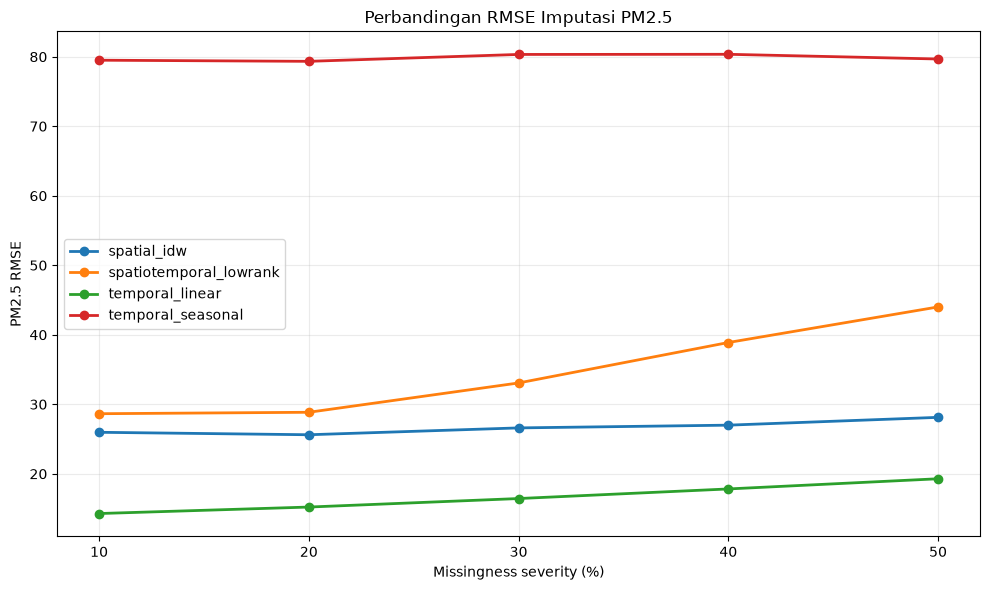

PM2.5 metrics:
method    spatial_idw  spatiotemporal_lowrank  temporal_linear  temporal_seasonal
severity                                                                         
10            25.9711                 28.6437          14.2833            79.5015
20            25.6180                 28.8509          15.2166            79.3398
30            26.6024                 33.0691          16.4404            80.3306
40            26.9974                 38.8872          17.8216            80.3517
50            28.1204                 44.0052          19.2857            79.6750

Varian temporal terpilih:
 severity          method      rmse
       10 temporal_linear 14.283340
       20 temporal_linear 15.216647
       30 temporal_linear 16.440362
       40 temporal_linear 17.821582
       50 temporal_linear 19.285702

Metrics tersimpan: d:\AI-Research\robust-pm-pred\rb-pm-pred\results\imputation_quality_metrics.csv
Grafik tersimpan: d:\AI-Research\robust-pm-pred\rb-pm-pred\results\f

In [8]:
imputation_results_df = pd.DataFrame(imputation_results)
metrics_path = RESULTS_DIR / "imputation_quality_metrics.csv"
imputation_results_df.to_csv(metrics_path, index=False)

pm25_metrics = imputation_results_df[imputation_results_df["column"] == "PM2.5"].copy()
best_temporal = pm25_metrics[pm25_metrics["method"].isin(["temporal_linear", "temporal_seasonal"])]
best_temporal = best_temporal.loc[best_temporal.groupby("severity")["rmse"].idxmin()]
for row in best_temporal.itertuples(index=False):
    temporal_df = temporal_outputs[int(row.severity)]["linear" if row.method == "temporal_linear" else "seasonal"]
    temporal_df.to_parquet(IMPUTED_DIR / f"temporal_severity_{int(row.severity)}.parquet", index=False)

plt.figure(figsize=(10, 6))
for method, method_data in pm25_metrics.groupby("method"):
    method_data = method_data.sort_values("severity")
    plt.plot(method_data["severity"], method_data["rmse"], marker="o", linewidth=2, label=method)
plt.xlabel("Missingness severity (%)")
plt.ylabel("PM2.5 RMSE")
plt.title("Perbandingan RMSE Imputasi PM2.5")
plt.xticks(SEVERITY_LEVELS)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
figure_path = FIGURES_DIR / "imputation_rmse_pm25.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("PM2.5 metrics:")
print(pm25_metrics.pivot(index="severity", columns="method", values="rmse").round(4).to_string())
print("\nVarian temporal terpilih:")
print(best_temporal[["severity", "method", "rmse"]].sort_values("severity").to_string(index=False))
print(f"\nMetrics tersimpan: {metrics_path}")
print(f"Grafik tersimpan: {figure_path}")

### VALID

## Interpretasi awal

Pada eksperimen ini, `temporal_linear` memiliki RMSE PM2.5 terendah pada seluruh severity 10%-50%, sehingga menjadi varian temporal yang disimpan sebagai `temporal_severity_XX.parquet`. `spatial_idw` berada di urutan kedua dan meningkat perlahan ketika missingness bertambah. `spatiotemporal_lowrank` tidak mengungguli IDW pada konfigurasi rank 4 dan 8 iterasi ini, sedangkan `temporal_seasonal` paling buruk karena rata-rata jam-hari dalam minggu terlalu halus untuk variasi PM2.5 lokal. Keunggulan temporal linear konsisten, tetapi hasil ini adalah evaluasi imputasi langsung dan belum merupakan hasil model prediksi.

## 7. Validation checklist

Checklist memastikan output siap dipakai sebagai input modeling: tidak ada NaN, jumlah kombinasi evaluasi cukup, durasi tercatat, dan grafik tersimpan.

In [9]:
required_output_templates = [
    "temporal_severity_{severity}.parquet",
    "spatial_severity_{severity}.parquet",
    "spatiotemporal_severity_{severity}.parquet",
]
all_outputs_valid = True
for severity in SEVERITY_LEVELS:
    for template in required_output_templates:
        output_path = IMPUTED_DIR / template.format(severity=severity)
        assert output_path.is_file(), f"File tidak ditemukan: {output_path.name}"
        output_df = pd.read_parquet(output_path)
        no_missing = int(output_df.isna().sum().sum()) == 0
        all_outputs_valid = all_outputs_valid and no_missing
        print(f"[{'x' if no_missing else ' '}] {output_path.name}: missing={int(output_df.isna().sum().sum())}")

metrics_from_disk = pd.read_csv(metrics_path)
pm25_rows = metrics_from_disk[metrics_from_disk["column"] == "PM2.5"]
metrics_valid = len(pm25_rows) >= 15
runtime_valid = metrics_from_disk["computation_time_sec"].notna().all() and (metrics_from_disk["computation_time_sec"] >= 0).all()
figure_valid = figure_path.is_file()
assert all_outputs_valid and metrics_valid and runtime_valid and figure_valid

print(f"[{'x' if metrics_valid else ' '}] Metrics PM2.5 memuat {len(pm25_rows)} baris")
print(f"[{'x' if runtime_valid else ' '}] Semua computation_time_sec tersedia")
print(f"[{'x' if figure_valid else ' '}] Grafik RMSE tersimpan di {figure_path}")
print("Validation checklist selesai: PASS")

[x] temporal_severity_10.parquet: missing=0
[x] spatial_severity_10.parquet: missing=0
[x] spatiotemporal_severity_10.parquet: missing=0
[x] temporal_severity_20.parquet: missing=0
[x] spatial_severity_20.parquet: missing=0
[x] spatiotemporal_severity_20.parquet: missing=0
[x] temporal_severity_30.parquet: missing=0
[x] spatial_severity_30.parquet: missing=0
[x] spatiotemporal_severity_30.parquet: missing=0
[x] temporal_severity_40.parquet: missing=0
[x] spatial_severity_40.parquet: missing=0
[x] spatiotemporal_severity_40.parquet: missing=0
[x] temporal_severity_50.parquet: missing=0
[x] spatial_severity_50.parquet: missing=0
[x] spatiotemporal_severity_50.parquet: missing=0
[x] Metrics PM2.5 memuat 20 baris
[x] Semua computation_time_sec tersedia
[x] Grafik RMSE tersimpan di d:\AI-Research\robust-pm-pred\rb-pm-pred\results\figures\imputation_rmse_pm25.png
Validation checklist selesai: PASS


### VALID